In [ ]:
import pandas as pd

df = pd.read_csv("Airline_data_5000.csv")

# Dataset Overview

In [3]:
print(df.info())
print(df.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   FlightID          5000 non-null   int64  
 1   FlightDate        5000 non-null   object 
 2   Airline           5000 non-null   object 
 3   DepartureAirport  5000 non-null   object 
 4   ArrivalAirport    5000 non-null   object 
 5   Class             5000 non-null   object 
 6   Passengers        5000 non-null   int64  
 7   TicketPrice       5000 non-null   float64
 8   DelayMinutes      5000 non-null   int64  
 9   Status            5000 non-null   object 
 10  Revenue           5000 non-null   float64
dtypes: float64(2), int64(3), object(6)
memory usage: 429.8+ KB
None
          FlightID   Passengers  TicketPrice  DelayMinutes        Revenue
count  5000.000000  5000.000000  5000.000000   5000.000000    5000.000000
mean   2500.500000   175.386000   431.816100     22.763200   7614

# Missing Values

In [4]:
print(df.isnull().sum())

FlightID            0
FlightDate          0
Airline             0
DepartureAirport    0
ArrivalAirport      0
Class               0
Passengers          0
TicketPrice         0
DelayMinutes        0
Status              0
Revenue             0
dtype: int64


# Top Airlines by Revenue

In [7]:
revenue = df.groupby("Airline")["Revenue"].sum()

print(revenue.sort_values(ascending=False))

Airline
Jin Air       67321799.74
T'way Air     65703943.75
Asiana        64870444.14
Jeju Air      62252233.44
Air Busan     60476392.67
Korean Air    60123755.69
Name: Revenue, dtype: float64


# Monthly Revenue Trend

In [8]:
df["FlightDate"] = pd.to_datetime(df["FlightDate"])

monthly = df.groupby(
    df["FlightDate"].dt.month
)["Revenue"].sum()

print(monthly)

FlightDate
1     33668076.87
2     28245080.87
3     33747021.66
4     27716393.20
5     29519098.12
6     33448559.29
7     32701324.80
8     31959393.37
9     31435766.42
10    32376263.10
11    28698434.77
12    37233156.96
Name: Revenue, dtype: float64


# Revenue Visualization

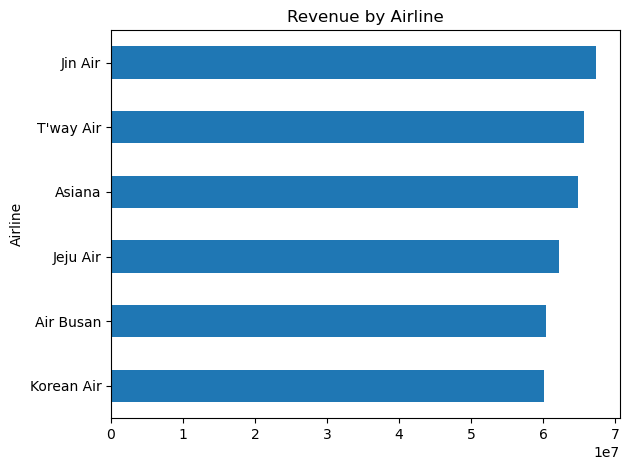

In [10]:
import matplotlib.pyplot as plt

revenue.sort_values().plot(kind="barh")

plt.title("Revenue by Airline")
plt.tight_layout()
plt.show()

# Delay Distribution

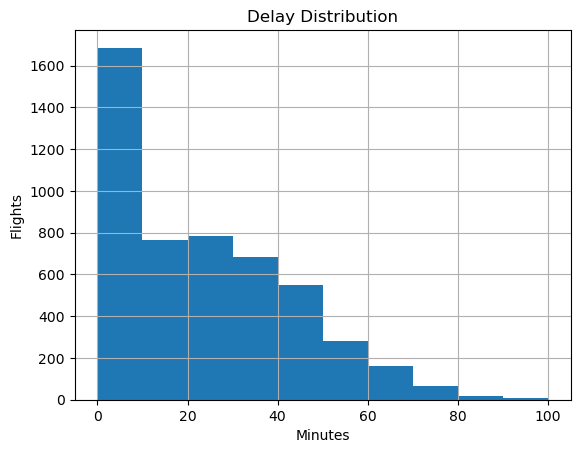

In [11]:
df["DelayMinutes"].hist()

plt.title("Delay Distribution")
plt.xlabel("Minutes")
plt.ylabel("Flights")
plt.show()

# Correlation Analysis

In [12]:
numeric = df[
    ["Passengers","TicketPrice","DelayMinutes","Revenue"]
    ]

print(numeric.corr())

              Passengers  TicketPrice  DelayMinutes   Revenue
Passengers      1.000000     0.026913      0.003896  0.622744
TicketPrice     0.026913     1.000000     -0.019131  0.738060
DelayMinutes    0.003896    -0.019131      1.000000 -0.014224
Revenue         0.622744     0.738060     -0.014224  1.000000


Passenger Count ↔ Revenue

Delay ↔ Revenue

Ticket Price ↔ Revenue